In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
top_n = 10

In [17]:
cancers = pd.read_csv('data/go_enrichment_++_cancers.csv', sep='\t')
cancer_top = cancers.sort_values("p_value").head(top_n).copy()
cancer_top["Group"] = "Cancer"

In [18]:
noncancers = pd.read_csv('data/go_enrichment_++_noncancers.csv', sep='\t')
non_cancer_top = noncancers.sort_values("p_value").head(top_n).copy()
non_cancer_top["Group"] = "Non-Cancer"

In [21]:
combined = pd.concat([cancer_top, non_cancer_top])
combined["-log10(p-value)"] = -np.log10(combined["p_value"])

In [25]:
combined

,Unnamed: 0,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,Group,-log10(p-value)
0,0,GO:BP,GO:0065007,biological regulation,7.059121e-72,True,"""Any process that modulates a measurable attri...",12671,2809,2124,21017,0.756141,0.167627,query_1,['GO:0008150'],Cancer,71.151249
1,1,GO:BP,GO:0048856,anatomical structure development,1.489350e-67,True,"""The biological process whose specific outcome...",5924,2809,1200,21017,0.427198,0.202566,query_1,['GO:0032502'],Cancer,66.827003
2,2,GO:BP,GO:0048518,positive regulation of biological process,4.606709e-67,True,"""Any process that activates or increases the f...",6235,2809,1245,21017,0.443218,0.199679,query_1,"['GO:0008150', 'GO:0050789']",Cancer,66.336609
3,3,GO:BP,GO:0050789,regulation of biological process,2.480846e-66,True,"""Any process that modulates the frequency, rat...",12278,2809,2060,21017,0.733357,0.167780,query_1,"['GO:0008150', 'GO:0065007']",Cancer,65.605400
4,4,GO:BP,GO:0048522,positive regulation of cellular process,7.964162e-66,True,"""Any process that activates or increases the f...",5886,2809,1189,21017,0.423282,0.202005,query_1,"['GO:0009987', 'GO:0048518', 'GO:0050794']",Cancer,65.098860
5,5,GO:BP,GO:0032502,developmental process,1.630448e-64,True,"""A biological process whose specific outcome i...",6478,2809,1273,21017,0.453186,0.196511,query_1,['GO:0008150'],Cancer,63.787693
6,6,GO:BP,GO:0007275,multicellular organism development,1.697194e-62,True,"""The biological process whose specific outcome...",4658,2809,990,21017,0.352439,0.212538,query_1,"['GO:0032501', 'GO:0048856']",Cancer,61.770268
7,7,GO:BP,GO:0050794,regulation of cellular process,4.821438e-62,True,"""Any process that modulates the frequency, rat...",11876,2809,1997,21017,0.710929,0.168154,query_1,"['GO:0009987', 'GO:0050789']",Cancer,61.316823
8,8,GO:MF,GO:0005515,protein binding,1.024896e-61,True,"""Binding to a protein."" [GOC:go_curators]",14865,2915,2499,20196,0.857290,0.168113,query_1,['GO:0005488'],Cancer,60.989320
9,9,GO:BP,GO:0032501,multicellular organismal process,7.549136e-61,True,"""Any biological process, occurring at the leve...",7234,2809,1371,21017,0.488074,0.189522,query_1,['GO:0008150'],Cancer,60.122103


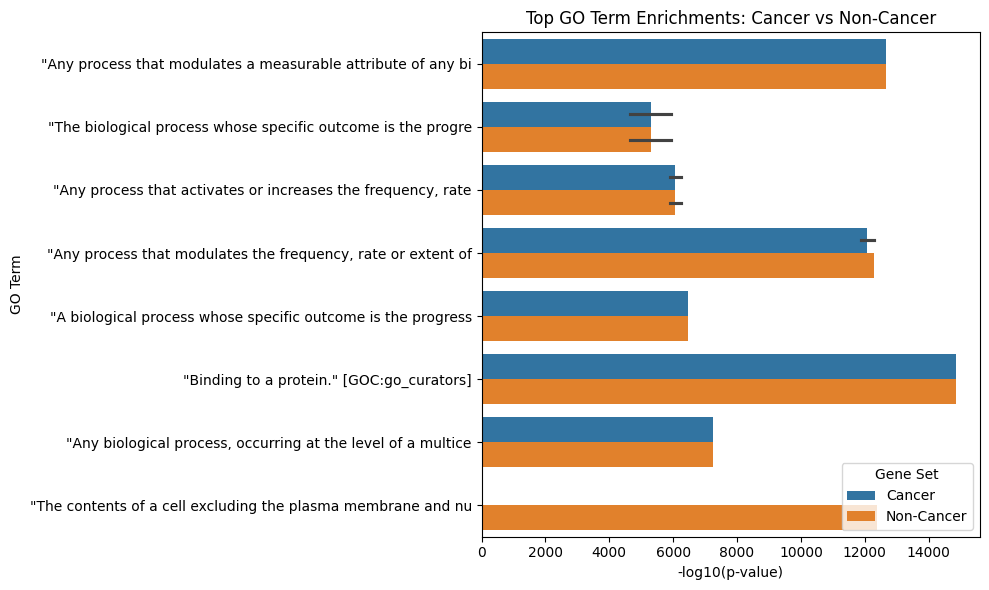

In [26]:
# Optional: Shorten long GO term descriptions
combined["description"] = combined["description"].str.slice(0, 60)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=combined,
    y="description",
    x="term_size",
    hue="Group",
    dodge=True
)
plt.xlabel("-log10(p-value)")
plt.ylabel("GO Term")
plt.title("Top GO Term Enrichments: Cancer vs Non-Cancer")
plt.legend(title="Gene Set")
plt.tight_layout()
plt.show()
